python

In [ ]:
from google.colab import files
files.upload()

Saving hiring (1).csv to hiring (1) (1).csv


{'hiring (1) (1).csv': b'\xef\xbb\xbfexperience,test_score(out of 10),interview_score(out of 10),salary($)\n,8,9,50000\n,8,6,45000\nfive,6,7,60000\ntwo,10,10,65000\nseven,9,6,70000\nthree,7,10,62000\nten,,7,72000\neleven,7,8,80000\n'}

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [ ]:
#load data
df = pd.read_csv("hiring (1).csv")
df.columns = ['experience', 'test_score', 'interview_score', 'salary']

In [ ]:
#fix missing values
df['experience'] = df['experience'].fillna(0)
df['test_score'] = df['test_score'].fillna(df['test_score'].mean())

In [ ]:
#convert word experience to numbers
words = {
    'zero':0,'one':1,'two':2,'three':3,'four':4,'five':5,
    'six':6,'seven':7,'eight':8,'nine':9,'ten':10,
    'eleven':11,'twelve':12
}
df['experience'] = df['experience'].apply(lambda x: words[x] if isinstance(x,str) else x)

In [ ]:
#train model
X = df[['experience','test_score','interview_score']]
y = df['salary']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [ ]:
#predict salary
candidates = pd.DataFrame({
    'experience': [2, 12],
    'test_score': [9, 10],
    'interview_score': [6, 10]
})

predicted_salaries = model.predict(candidates)
predicted_salaries

array([53290.89255945, 92268.07227784])

Let's first look at the coefficients and the intercept of the trained linear regression model:

In [ ]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# To make it more readable, let's associate coefficients with their features
feature_names = X.columns
coefficients = model.coef_

coeff_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})
display(coeff_df)

Coefficients: [2827.63404314 1912.93803053 2196.9753141 ]
Intercept: 17237.330313727172


,Feature,Coefficient
0,experience,2827.634043
1,test_score,1912.938031
2,interview_score,2196.975314


Let's visualize the relationship between 'experience' and 'salary' using a scatter plot.

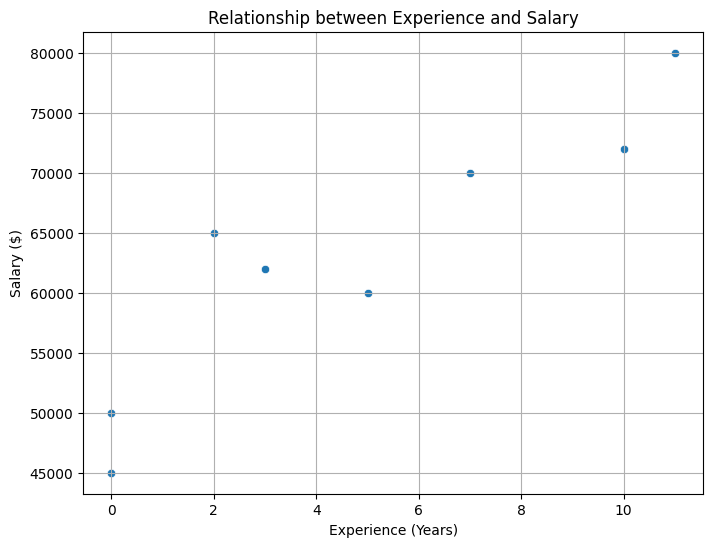

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='experience', y='salary', data=df)
plt.title('Relationship between Experience and Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary ($)')
plt.grid(True)
plt.show()

This scatter plot shows the distribution of salaries across different levels of experience. Each point represents an individual data entry. We can observe a general trend from this plot: as experience increases, the salary tends to increase, which is consistent with our linear regression model's positive coefficient for 'experience'.

### Explanation of Coefficients:

*   **Experience:** For every additional year of experience, the predicted salary increases by approximately `model.coef_[0]` dollars, assuming test score and interview score remain constant.
*   **Test Score:** For every one-point increase in the test score, the predicted salary increases by approximately `model.coef_[1]` dollars, assuming experience and interview score remain constant.
*   **Interview Score:** For every one-point increase in the interview score, the predicted salary increases by approximately `model.coef_[2]` dollars, assuming experience and test score remain constant.
*   **Intercept:** The intercept `model.intercept_` represents the baseline predicted salary when all other variables (experience, test score, interview score) are zero.